In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.metrics import mean_absolute_percentage_error


Matplotlib is building the font cache; this may take a moment.


In [2]:

np.random.seed(42)

dates = pd.date_range(start="2020-01-01", periods=60, freq="MS")

trend       = np.linspace(100, 300, 60)
seasonality = 20 * np.sin(2 * np.pi * dates.month / 12)
noise       = np.random.normal(0, 10, 60)

sales = trend + seasonality + noise

df = pd.DataFrame({"Date": dates, "Sales": sales}).set_index("Date")


In [3]:

df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 60 entries, 2020-01-01 to 2024-12-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Sales   60 non-null     float64
dtypes: float64(1)
memory usage: 960.0 bytes


Creating Features : Build Lag + Rolling + Calendar features

In [4]:

def create_features(data, target_col, lags):
    df = data.copy()

    # Lag features
    for lag in lags:
        df[f"lag_{lag}"] = df[target_col].shift(lag)

    # Rolling features (shifted to avoid leakage)
    df["rolling_mean_3"] = df[target_col].shift(1).rolling(3).mean()
    df["rolling_mean_6"] = df[target_col].shift(1).rolling(6).mean()
    df["rolling_std_3"]  = df[target_col].shift(1).rolling(3).std()

    # Calendar features
    df["month"]   = df.index.month
    df["quarter"] = df.index.quarter
    df["year"]    = df.index.year

    return df


lags = [1, 2, 3, 6, 12]
df_model = create_features(df, "Sales", lags).dropna()


In [5]:
df_model.head()

,Sales,lag_1,lag_2,lag_3,lag_6,lag_12,rolling_mean_3,rolling_mean_6,rolling_std_3,month,quarter,year
Date,,,,,,,,,,,,
2021-01-01,153.097589,132.630838,119.264128,118.613567,126.131111,114.967142,123.502844,118.857700,7.911764,1,1,2021
2021-02-01,142.255502,153.097589,132.630838,119.264128,114.082653,119.327696,134.997518,123.352112,17.040442,2,1,2021
2021-03-01,150.208449,142.255502,153.097589,132.630838,102.423900,133.256546,142.661310,128.047587,10.239408,3,1,2021
2021-04-01,162.545090,150.208449,142.255502,153.097589,118.613567,142.720298,148.520513,136.011679,5.614673,4,2,2021
2021-05-01,154.108977,162.545090,150.208449,142.255502,119.264128,121.217788,151.669680,143.333599,10.223417,5,2,2021


In [6]:

train = df_model.iloc[:-12]
test  = df_model.iloc[-12:]

feature_cols = [c for c in df_model.columns if c != "Sales"]

X_train, y_train = train[feature_cols], train["Sales"]
X_test,  y_test  = test[feature_cols],  test["Sales"]



In [7]:
y_train.head()

Date
2021-01-01    153.097589
2021-02-01    142.255502
2021-03-01    150.208449
2021-04-01    162.545090
2021-05-01    154.108977
Name: Sales, dtype: float64

Random Forest

In [8]:

rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=6,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rf_mape = mean_absolute_percentage_error(y_test, rf_preds)
print(f"Random Forest MAPE: {rf_mape:.2%}")


Random Forest MAPE: 11.56%


XGBoost

In [9]:

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

xgb_mape = mean_absolute_percentage_error(y_test, xgb_preds)

print(f"XGBoost MAPE: {xgb_mape:.2%}")


XGBoost MAPE: 15.15%


LightGBM

In [10]:

lgb_model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=15,             # ↓ smaller trees for small data
    min_data_in_leaf=2,        # ↓ allow small leaves
    min_data_in_bin=1,         # ↓ allow small bins
    min_gain_to_split=0.0,     # allow any positive gain
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    verbose=-1                 # silence the info logs
)

lgb_model.fit(X_train, y_train)

lgb_preds = lgb_model.predict(X_test)
lgb_mape = mean_absolute_percentage_error(y_test, lgb_preds)


In [11]:
print(f"Random Forest MAPE: {rf_mape:.2%}")
print(f"XGBoost MAPE: {xgb_mape:.2%}")
print(f"LightGBM MAPE: {lgb_mape:.2%}")

Random Forest MAPE: 11.56%
XGBoost MAPE: 15.15%
LightGBM MAPE: 8.54%


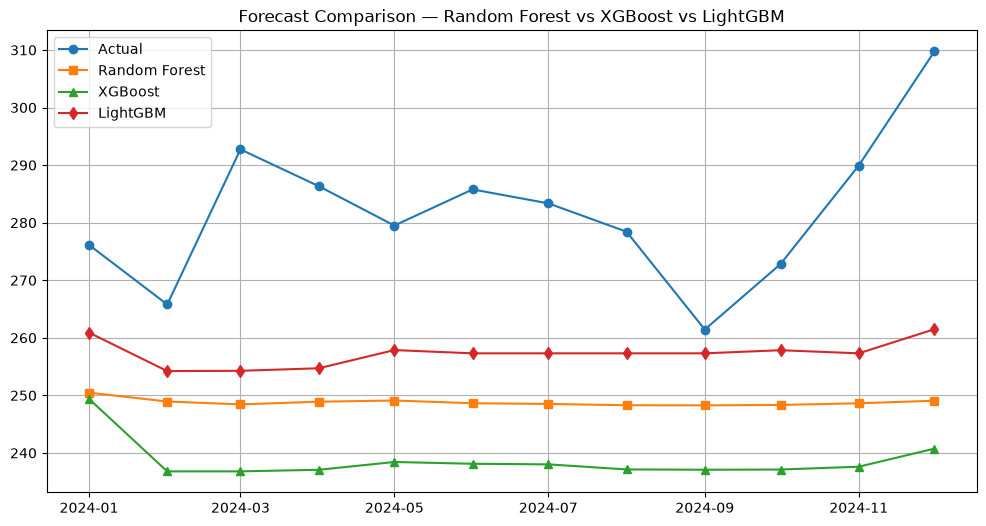

In [12]:

plt.figure(figsize=(12,6))

plt.plot(y_test.index, y_test,     label="Actual",       marker="o")
plt.plot(y_test.index, rf_preds,   label="Random Forest", marker="s")
plt.plot(y_test.index, xgb_preds,  label="XGBoost",       marker="^")
plt.plot(y_test.index, lgb_preds,  label="LightGBM",      marker="d")

plt.title("Forecast Comparison — Random Forest vs XGBoost vs LightGBM")
plt.legend()
plt.grid(True)
plt.show()


Feature Importance

<Axes: title={'center': 'Random Forest Importance'}>

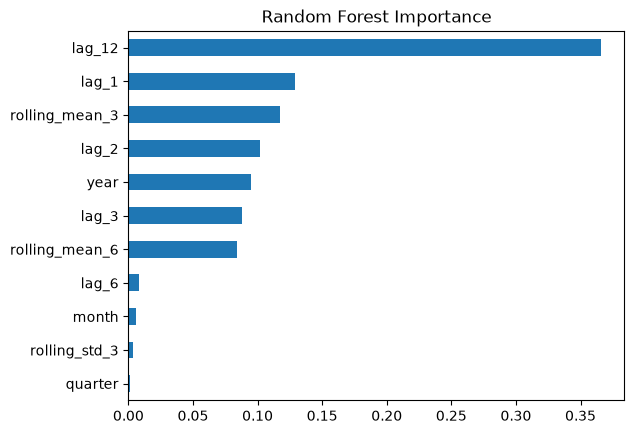

In [13]:

pd.Series(rf_model.feature_importances_, index=feature_cols)\
    .sort_values().plot(kind="barh", title="Random Forest Importance")


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

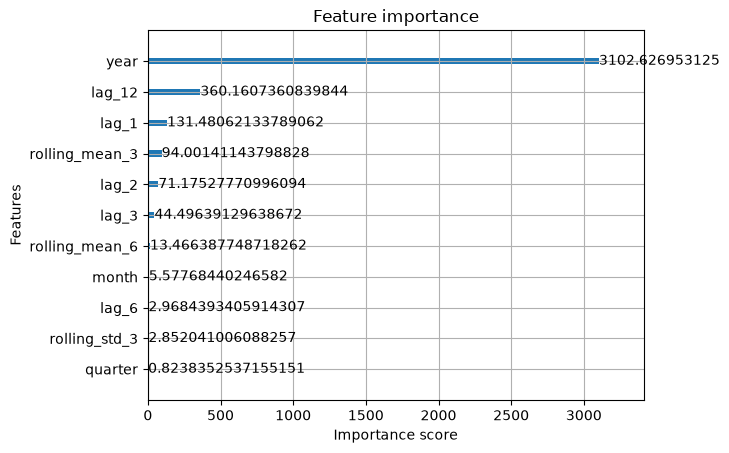

In [14]:

import xgboost as xgb
xgb.plot_importance(xgb_model, importance_type="gain")


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

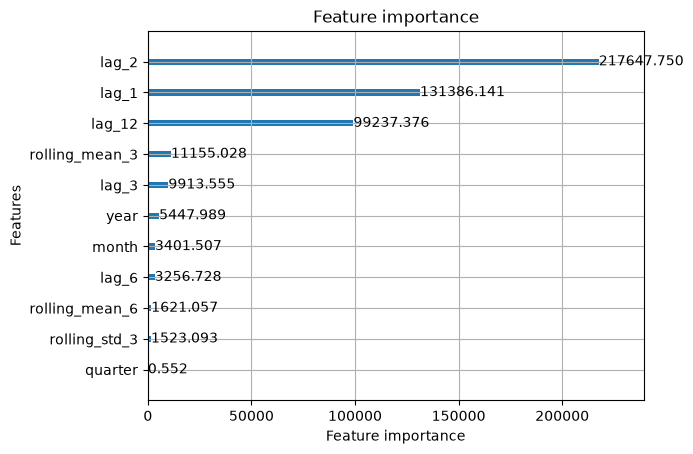

In [15]:

import lightgbm as lgb
lgb.plot_importance(lgb_model, importance_type="gain")


In [16]:

def recursive_forecast(model, history_df, steps, feature_cols, lags):
    history = history_df.copy()
    forecasts = []

    for _ in range(steps):
        next_date = history.index[-1] + pd.DateOffset(months=1)
        row = {}

        for lag in lags:
            row[f"lag_{lag}"] = history["Sales"].iloc[-lag]

        row["rolling_mean_3"] = history["Sales"].iloc[-3:].mean()
        row["rolling_mean_6"] = history["Sales"].iloc[-6:].mean()
        row["rolling_std_3"]  = history["Sales"].iloc[-3:].std()

        row["month"]   = next_date.month
        row["quarter"] = next_date.quarter
        row["year"]    = next_date.year

        X_next = pd.DataFrame([row])[feature_cols]
        pred = model.predict(X_next)[0]

        forecasts.append((next_date, pred))
        history.loc[next_date, "Sales"] = pred

    return pd.DataFrame(forecasts, columns=["Date","Forecast"]).set_index("Date")


In [17]:
future_xgb = recursive_forecast(xgb_model, df, 12, feature_cols, lags)
print(future_xgb)

              Forecast
Date                  
2025-01-01  238.117264
2025-02-01  235.848938
2025-03-01  237.695572
2025-04-01  241.665146
2025-05-01  253.792831
2025-06-01  241.485046
2025-07-01  247.434723
2025-08-01  246.533569
2025-09-01  246.192398
2025-10-01  247.709229
2025-11-01  248.280304
2025-12-01  251.247513
